https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv



Research question: How did students score on Common Core English Vs. Common Core Algebra at Frank Sinatra School of the Arts, and how does this compare to students in the rest of Queens?

In [41]:
#import pandas, matplotlib and the data set
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv ('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

In [143]:
#take a look at the first few rows to see what the data set looks like
df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Num Scoring College Readiness,Pct Scoring College Readiness,Borough
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na,Manhattan
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na,Manhattan
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na,Manhattan
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na,Manhattan
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na,Manhattan


In [43]:
#how many rows and columns are in this data set?
df.shape

(212331, 15)

In [44]:
#what are the column headers, what data is available to us to work with?
df.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

In [45]:
#how many different schools are in this data set
df['School Name'].nunique()

1012

In [46]:
#what are the data types in this data set
df.dtypes

,0
School DBN,object
School Name,object
School Level,object
Regents Exam,object
Year,int64
Total Tested,int64
Mean Score,object
Number Scoring Below 65,object
Percent Scoring Below 65,object
Number Scoring 65 or Above,object


In [55]:
#convert school DBN to borough name, store in a new column called Borough

borough_codes = {
    'M': 'Manhattan',
    'X': 'Bronx',
    'K': 'Brooklyn',
    'Q': 'Queens',
    'R': 'Staten Island'
}

df['Borough'] = df['School DBN'].str[2].map(borough_codes)

df [['School DBN' , 'Borough']]

,School DBN,Borough
0,01M034,Manhattan
1,01M034,Manhattan
2,01M034,Manhattan
3,01M140,Manhattan
4,01M140,Manhattan
...,...,...
212326,84X717,Bronx
212327,84X717,Bronx
212328,84X717,Bronx
212329,84X717,Bronx


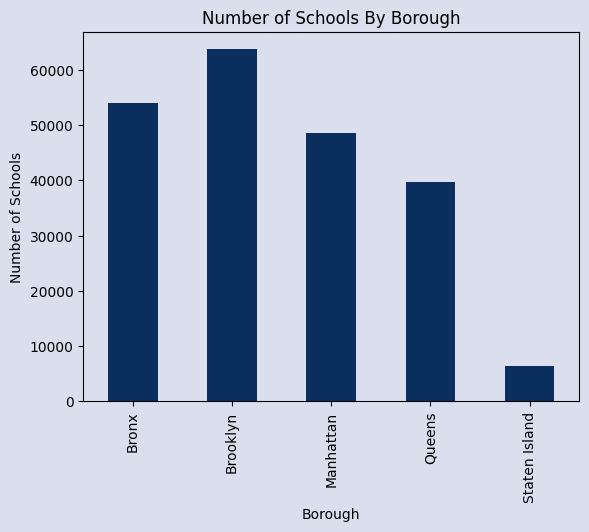

In [62]:
#count how many schools are in each borough

#df.groupby(['Borough']) ['Borough'].count().

colors = ['#0a2f5e']
ax = df.groupby(['Borough']) ['Borough'].count().plot.bar(stacked = 'true',
title = 'Number of Schools By Borough', ylabel = 'Number of Schools', xlabel = 'Borough', color = colors)
ax.set_facecolor('#dadeed')
ax.figure.set_facecolor('#dadeed');

In [66]:
#What subjects were part of the Regents Exam, and what years were they tested

df.groupby(['Regents Exam', 'Year']) ['Regents Exam'].count()

Regents Exam                     Year
Algebra2/Trigonometry            2015     4379
                                 2016     4396
                                 2017     2013
Common Core Algebra              2015     9126
                                 2016     9804
                                 2017    10324
Common Core Algebra2             2016     3533
                                 2017     4382
Common Core English              2015     4957
                                 2016     7331
                                 2017     7590
Common Core Geometry             2015     4394
                                 2016     5370
                                 2017     5503
English                          2015     6313
                                 2016     4778
Geometry                         2015     5268
                                 2016     3206
                                 2017       35
Global History and Geography     2015     6361
                                 2016     6440
                                 2017     6391
Integrated Algebra               2015     6310
                                 2016     4667
                                 2017       45
Living Environment               2015     8156
                                 2016     8456
                                 2017     8927
Physical Settings/Chemistry      2015     3803
                                 2016     3901
                                 2017     3966
Physical Settings/Earth Science  2015     5254
                                 2016     5409
                                 2017     5308
Physical Settings/Physics        2015     1898
                                 2016     1913
                                 2017     1988
U.S. History and Government      2015     6539
                                 2016     6919
                                 2017     6968
Name: Regents Exam, dtype: int64

In [70]:
#let's look at one school, see if you can find Frank Sinatra School of the Arts (local to me) by looking up its DBN online, then plugging it in
df [df['School DBN'] == '30Q501']

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR,Borough
16591,30Q501,Frank Sinatra School of the Arts High School,High school,Algebra2/Trigonometry,2015,178,64.5,81,45.5,97,54.5,27,15.2,27,15.2,Queens
16592,30Q501,Frank Sinatra School of the Arts High School,High school,Algebra2/Trigonometry,2016,207,60,122,58.9,85,41.1,31,15,31,15,Queens
16593,30Q501,Frank Sinatra School of the Arts High School,High school,Algebra2/Trigonometry,2017,5,s,s,s,s,s,s,s,na,na,Queens
16594,30Q501,Frank Sinatra School of the Arts High School,High school,Common Core Algebra,2015,143,68.6,28,19.6,115,80.4,8,5.6,82,57.3,Queens
16595,30Q501,Frank Sinatra School of the Arts High School,High school,Common Core Algebra,2016,147,73.4,24,16.3,123,83.7,40,27.2,107,72.8,Queens
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202836,30Q501,Frank Sinatra School of the Arts High School,High school,U.S. History and Government,2017,26,s,s,s,s,s,s,s,na,na,Queens
202837,30Q501,Frank Sinatra School of the Arts High School,High school,U.S. History and Government,2017,34,85.7,1,2.9,33,97.1,27,79.4,na,na,Queens
202838,30Q501,Frank Sinatra School of the Arts High School,High school,U.S. History and Government,2017,67,88,2,3,65,97,57,85.1,na,na,Queens
202839,30Q501,Frank Sinatra School of the Arts High School,High school,U.S. History and Government,2017,4,s,s,s,s,s,s,s,na,na,Queens


In [108]:
#How did the students score at Common Core English vs. Common Core Math at Frank Sinatra School of The Arts High School

#Rename the columns Percent Scoring CR and Number Scoring CR
df.rename(columns={'Number Scoring CR' : 'Num Scoring College Readiness', 'Percent Scoring CR': 'Pct Scoring College Readiness'})

#create simpler data frame with only the columns we need

df2 = df[['School Name', 'Borough','Regents Exam', 'Year', 'Total Tested', 'Num Scoring College Readiness', 'Pct Scoring College Readiness']]

#Filter for Frank Sinatra HS and also Common Core English/Algebra
df3 = df2[
    (df2['School Name'] == 'Frank Sinatra School of the Arts High School') &
    (df2 ['Year'] == 2017) &
    (df2['Regents Exam'].isin(['Common Core English', 'Common Core Algebra']))
]

df3.head(50)
#This data is confusing, I'm uncertain why the tests were administered so many times in the course of one year, I thought a subject was tested only
# 3 times per year. There are also a lot of NA values.
#Let's drop the NA values and group the results to simplify (see below)

,School Name,Borough,Regents Exam,Year,Total Tested,Num Scoring College Readiness,Pct Scoring College Readiness
16596,Frank Sinatra School of the Arts High School,Queens,Common Core Algebra,2017,129,93,72.1
16600,Frank Sinatra School of the Arts High School,Queens,Common Core English,2017,217,207,95.4
49084,Frank Sinatra School of the Arts High School,Queens,Common Core Algebra,2017,81,72,88.9
49085,Frank Sinatra School of the Arts High School,Queens,Common Core Algebra,2017,48,21,43.8
49092,Frank Sinatra School of the Arts High School,Queens,Common Core English,2017,201,198,98.5
49093,Frank Sinatra School of the Arts High School,Queens,Common Core English,2017,16,9,56.3
96060,Frank Sinatra School of the Arts High School,Queens,Common Core Algebra,2017,2,na,na
96061,Frank Sinatra School of the Arts High School,Queens,Common Core Algebra,2017,112,82,73.2
96062,Frank Sinatra School of the Arts High School,Queens,Common Core Algebra,2017,15,na,na
96069,Frank Sinatra School of the Arts High School,Queens,Common Core English,2017,1,na,na


In [115]:
#drop na values
df3 = df3[df3['Num Scoring College Readiness'] != 'na']

#groupby and sum
df3.groupby (['Regents Exam']) ['Total Tested'].sum()

,Total Tested
Regents Exam,
Common Core Algebra,617
Common Core English,1024


In [130]:
#Convert data type from text to number
df3['Pct Scoring College Readiness'] = pd.to_numeric(
    df3['Pct Scoring College Readiness'],
    errors='coerce'
)

#What are the descriptive stats for these two subjects?
df3.groupby('Regents Exam')['Pct Scoring College Readiness'].describe()



,count,mean,std,min,25%,50%,75%,max
Regents Exam,,,,,,,,
Common Core Algebra,9.0,70.644444,12.855943,43.8,65.4,72.1,77.6,88.9
Common Core English,9.0,91.244444,13.213261,56.3,94.1,95.4,96.2,98.5


In [131]:
#what is the median percentage
df3.groupby('Regents Exam')['Pct Scoring College Readiness'].median()



,Pct Scoring College Readiness
Regents Exam,
Common Core Algebra,72.1
Common Core English,95.4


In [132]:
#How did the rest of the students in Queens fare in these subjects?

#Create a new DF using the same filter, but for all of Queens

df4 = df2[
    (df2['Borough'] == 'Queens') &
    (df2 ['Year'] == 2017) &
    (df2['Regents Exam'].isin(['Common Core English', 'Common Core Algebra']))
]

df4.head()


,School Name,Borough,Regents Exam,Year,Total Tested,Num Scoring College Readiness,Pct Scoring College Readiness
13366,I.S. 5 - The Walter Crowley Intermediate School,Queens,Common Core Algebra,2017,92,90,97.8
13367,I.S. 5 - The Walter Crowley Intermediate School,Queens,Common Core English,2017,1,na,na
13377,P.S. 049 Dorothy Bonawit Kole,Queens,Common Core Algebra,2017,38,36,94.7
13384,I.S. 061 Leonardo Da Vinci,Queens,Common Core Algebra,2017,150,131,87.3
13386,I.S. 061 Leonardo Da Vinci,Queens,Common Core English,2017,1,na,na


In [133]:
#drop na values
df4 = df4[df4['Num Scoring College Readiness'] != 'na']

#groupby and sum
df4.groupby (['Regents Exam']) ['Total Tested'].sum()

,Total Tested
Regents Exam,
Common Core Algebra,159436
Common Core English,114037


In [134]:
#Convert data type from text to number
df4['Pct Scoring College Readiness'] = pd.to_numeric(
    df4['Pct Scoring College Readiness'],
    errors='coerce'
)

#What are the descriptive stats for these two subjects in all of Queens
df4.groupby('Regents Exam')['Pct Scoring College Readiness'].describe()


,count,mean,std,min,25%,50%,75%,max
Regents Exam,,,,,,,,
Common Core Algebra,1439.0,65.532036,28.250291,0.0,41.95,68.0,93.3,100.0
Common Core English,945.0,58.665079,25.223768,0.0,40.40,59.2,79.2,100.0


In [135]:
#what is the median percentage
df4.groupby('Regents Exam')['Pct Scoring College Readiness'].median()

,Pct Scoring College Readiness
Regents Exam,
Common Core Algebra,68.0
Common Core English,59.2


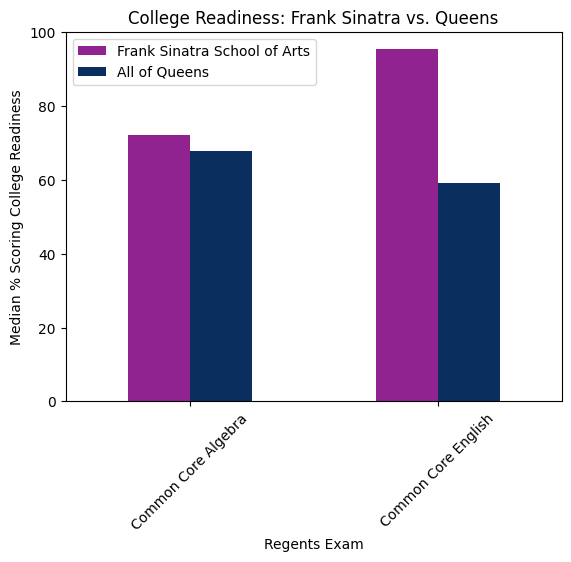

In [141]:
#plot results on a bar chart, compare Frank Sinatra HS and all of Queens

df3_median = df3.groupby('Regents Exam')['Pct Scoring College Readiness'].median()

df4_median = df4.groupby('Regents Exam')['Pct Scoring College Readiness'].median()

comparison = pd.DataFrame({
    'Frank Sinatra School of Arts': df3_median,
    'All of Queens': df4_median
})

comparison.plot(kind='bar',
color=['#912390', '#0a2f5e'])

plt.ylabel('Median % Scoring College Readiness')
plt.xlabel('Regents Exam')
plt.title('College Readiness: Frank Sinatra vs. Queens')
plt.xticks(rotation=45)
plt.legend()
plt.show()

**Conclusions/Findings:**  This data set needed a fair amount of cleaning, and questions remain about why so many tests per year were issued. By comparing Common Core Algebra and Common Core English at Frank Sinatra School of The Arts High School in 2017, we see that the students are much more prepared in Common Core English than they are in Common Core Algebra. To me, this finding is somewhat expected, as the curriculum at a performing arts school tends to be more rigorous in English Literature and Humanities, and less so in Math and Sciences.  Compared to the rest of Queens, the students at FSSAHS had median percentage scores that were higher than the rest of the borough, with the Common Core English scoring much higher, and the Common Core Algebra slightly higher. Interestingly, the rest of Queens scored higher in Common Core Algebra than Common Core English, suggesting a more rigorous curriculum in Algebra compared to English in the rest of the borough.